📁 Caricare il file 'london_weather.csv'


Saving london_weather.csv to london_weather (1).csv
✅ Dataset caricato
Colonne: ['date', 'cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth']
Duplicati: 0
Soglia pioggia: 0.2000 mm
Distribuzione target:
y
0    0.60674
1    0.39326
Name: proportion, dtype: float64


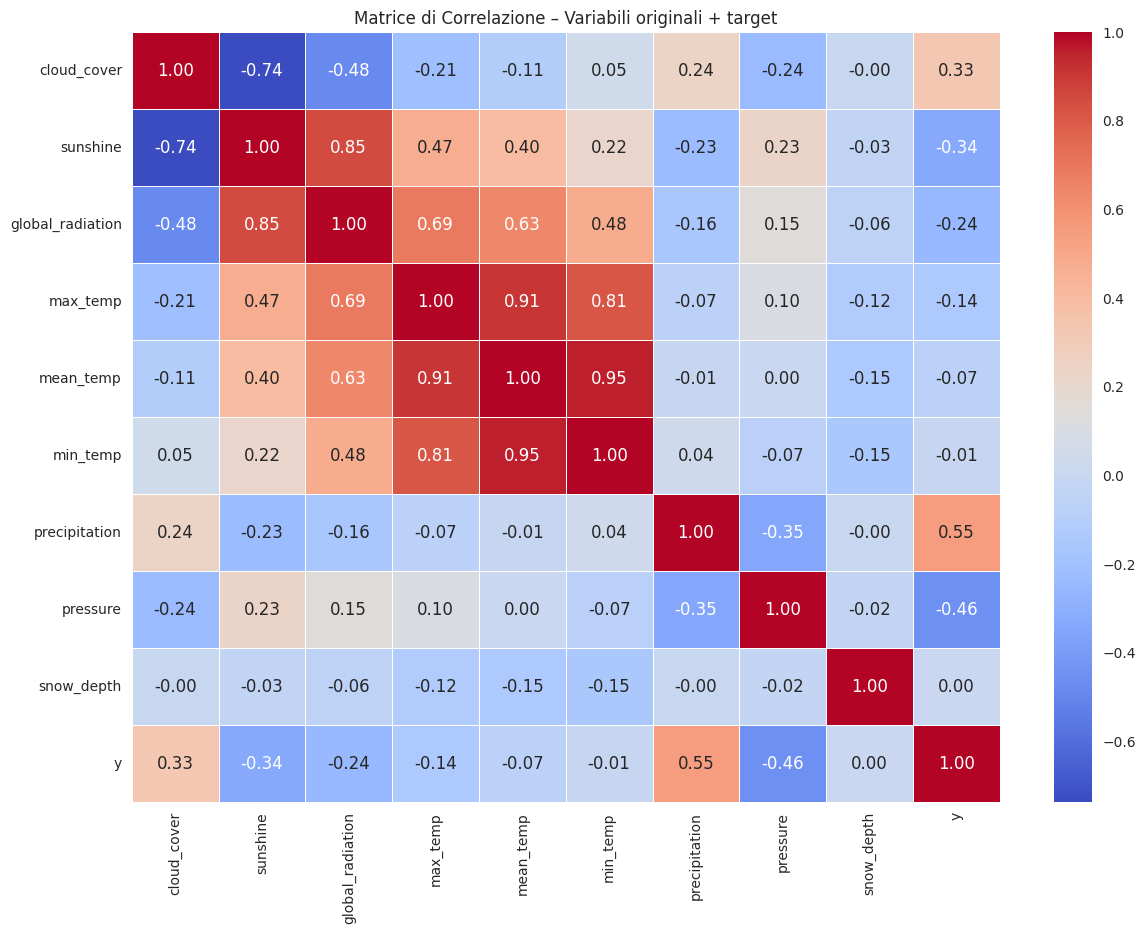

Feature selezionate: 21


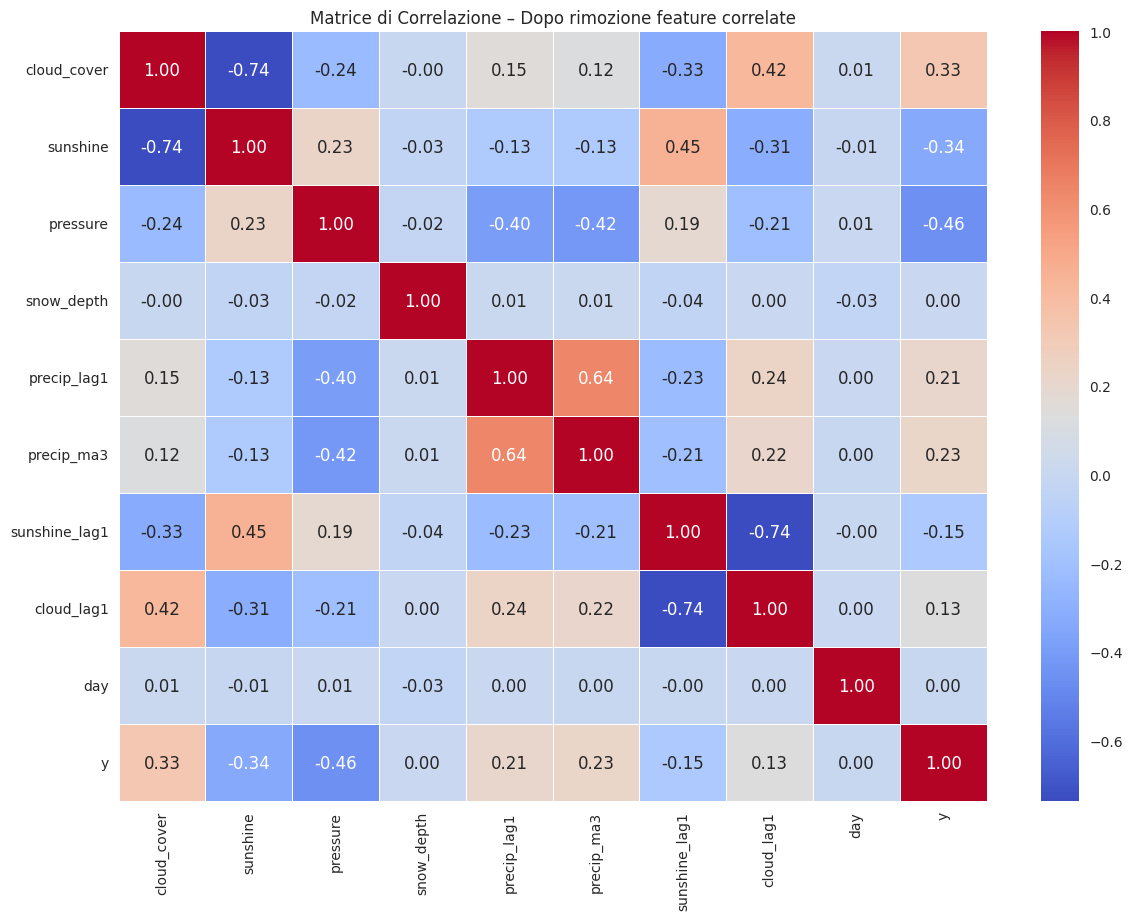

Training set: 14610 campioni
Test set:     731 campioni
Distribuzione target training:
y
0    0.608077
1    0.391923
Name: proportion, dtype: float64

--- LogisticRegression ---
F1-weighted CV: 0.7417 (+/- 0.0122)
Test Accuracy: 0.7661

--- DecisionTree ---
F1-weighted CV: 0.6696 (+/- 0.0084)
Test Accuracy: 0.6484

--- RandomForest ---
F1-weighted CV: 0.7409 (+/- 0.0114)
Test Accuracy: 0.7579

--- XGBoost ---
F1-weighted CV: 0.7213 (+/- 0.0092)
Test Accuracy: 0.7387

--- SVC ---
F1-weighted CV: 0.7410 (+/- 0.0105)
Test Accuracy: 0.7702

✓ Completato.
            Algorithm   CV Mean    CV Std  Test Accuracy
0  LogisticRegression  0.741660  0.012184       0.766074
4                 SVC  0.741024  0.010508       0.770178
2        RandomForest  0.740892  0.011366       0.757866
3             XGBoost  0.721305  0.009220       0.738714
1        DecisionTree  0.669632  0.008415       0.648427


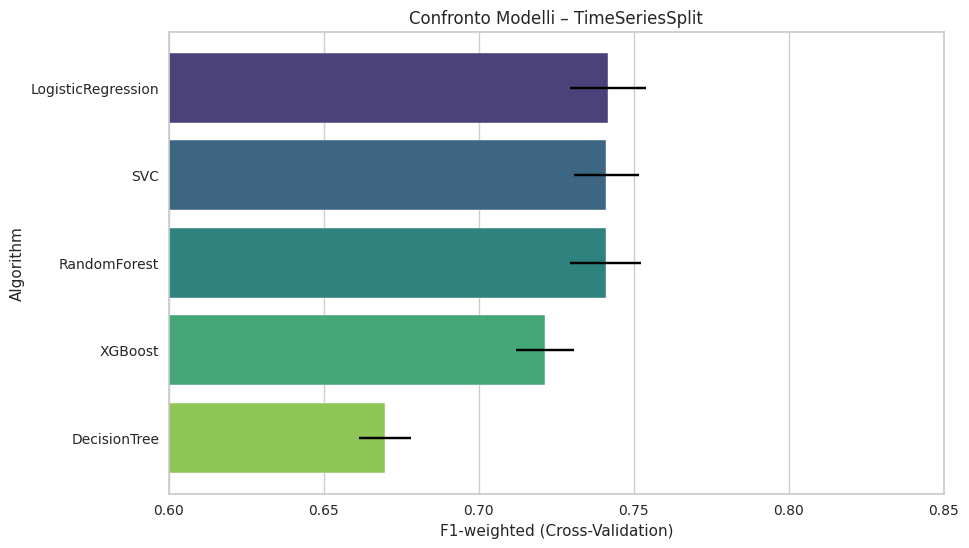

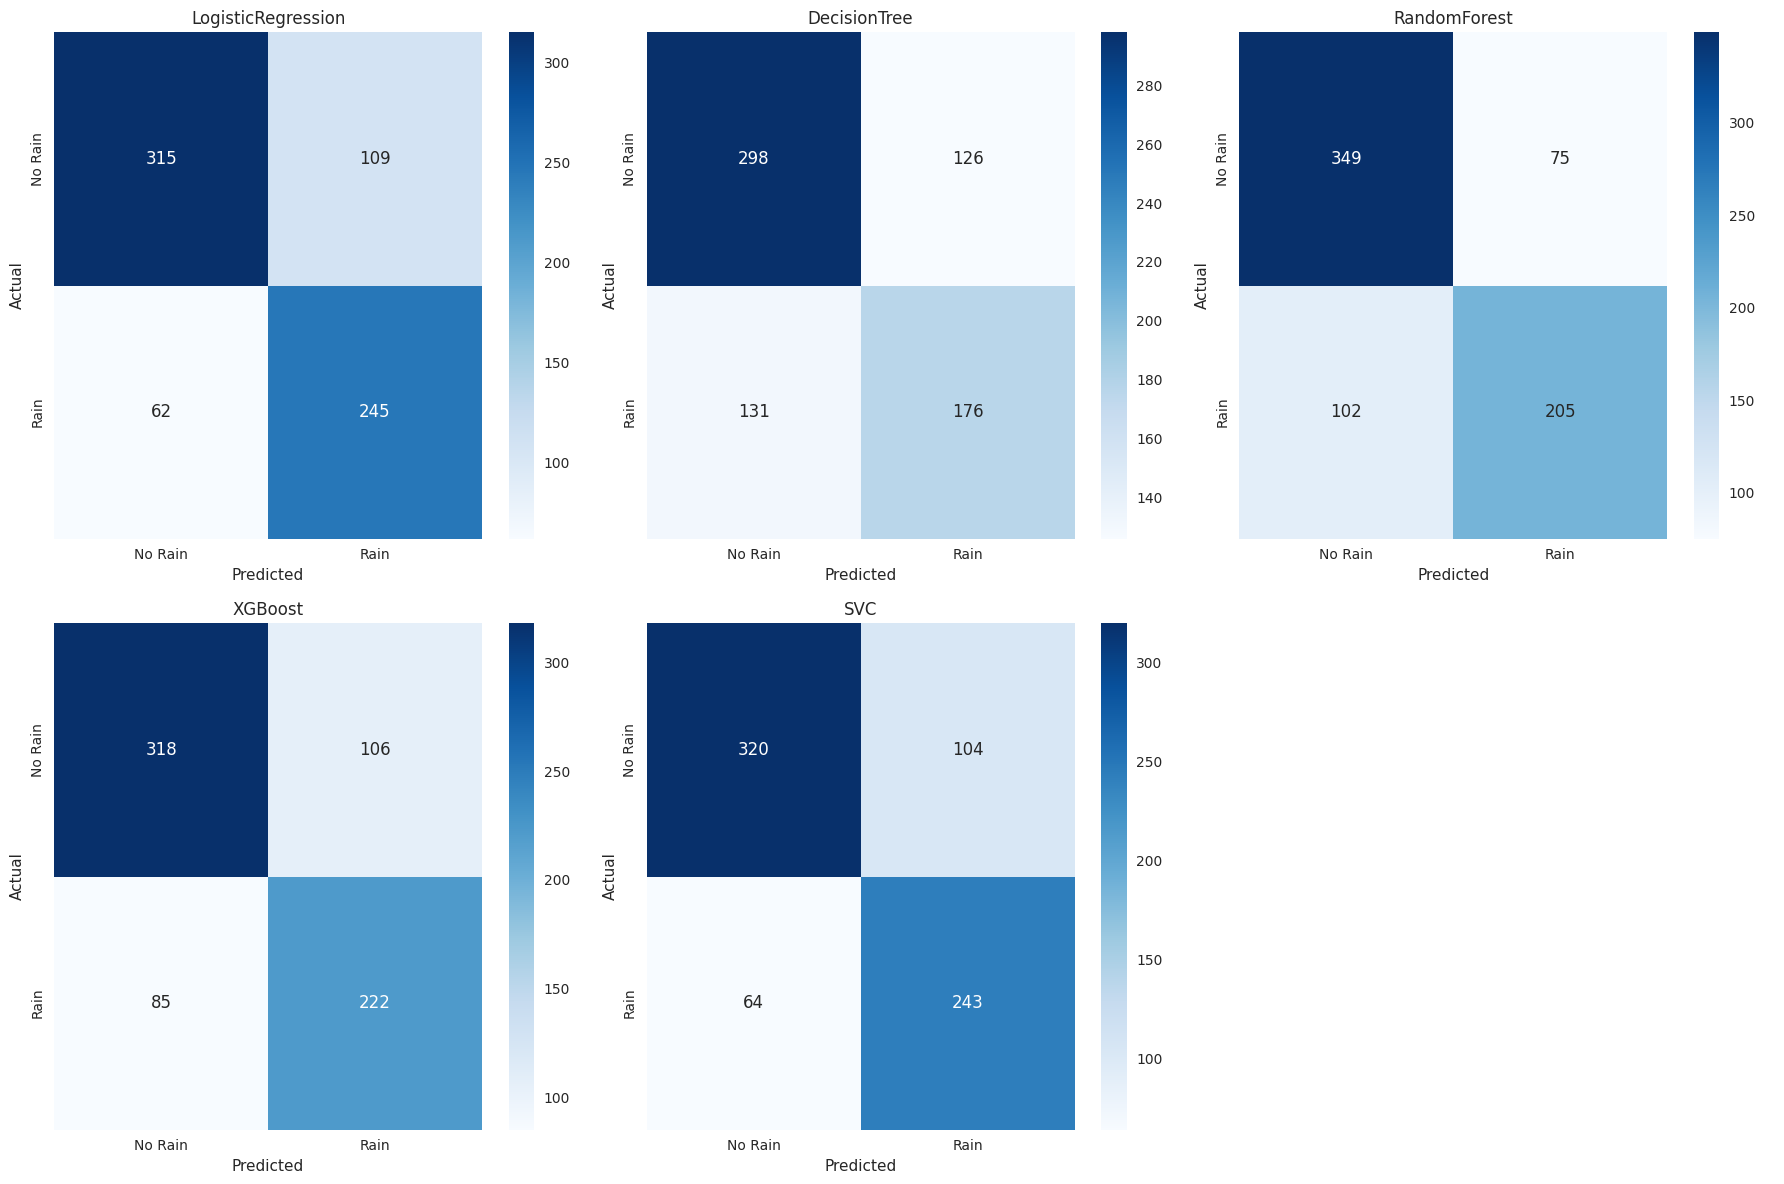


=== LogisticRegression ===
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       424
           1       0.69      0.80      0.74       307

    accuracy                           0.77       731
   macro avg       0.76      0.77      0.76       731
weighted avg       0.78      0.77      0.77       731


=== DecisionTree ===
              precision    recall  f1-score   support

           0       0.69      0.70      0.70       424
           1       0.58      0.57      0.58       307

    accuracy                           0.65       731
   macro avg       0.64      0.64      0.64       731
weighted avg       0.65      0.65      0.65       731


=== RandomForest ===
              precision    recall  f1-score   support

           0       0.77      0.82      0.80       424
           1       0.73      0.67      0.70       307

    accuracy                           0.76       731
   macro avg       0.75      0.75      0.75       731
we

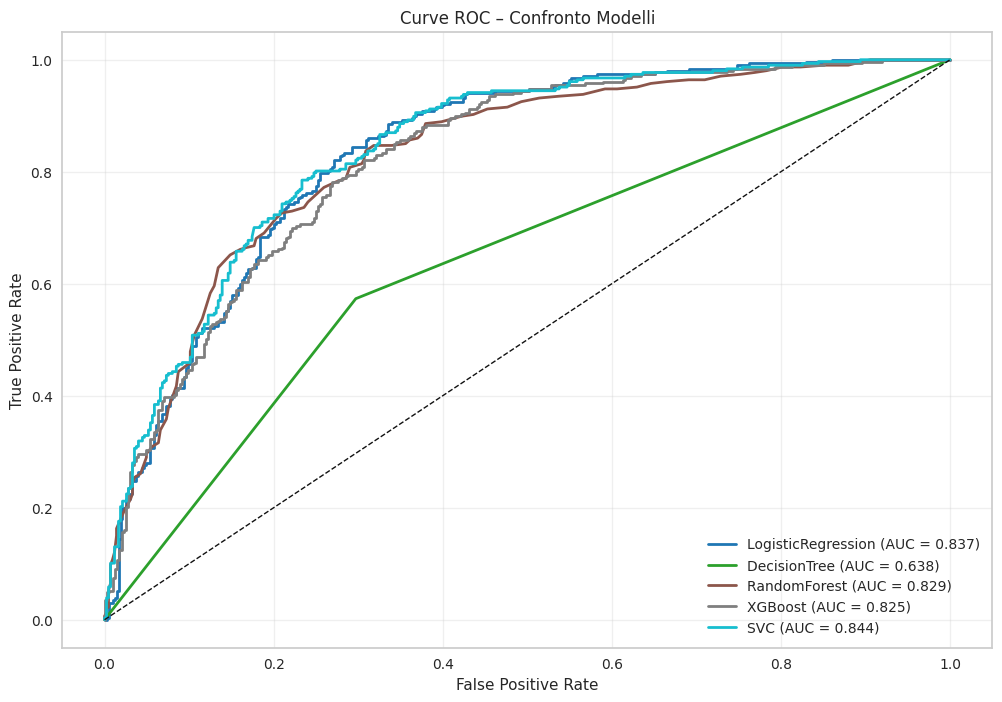

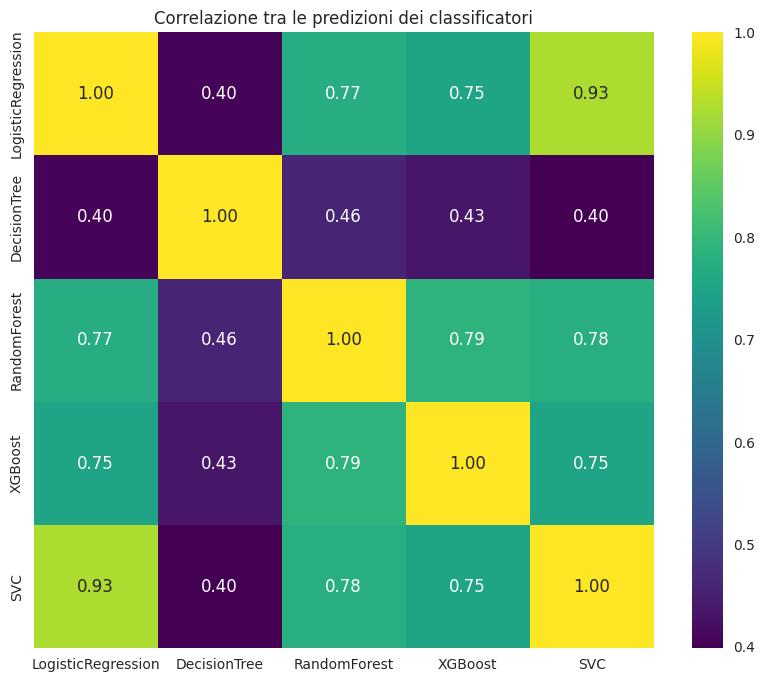


=== GridSearch per RandomForest ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Migliori parametri: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
F1-weighted CV:     0.7449

=== GridSearch per XGBoost ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Migliori parametri: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
F1-weighted CV:     0.7436

=== VOTING CLASSIFIER ===
Accuracy:            0.7551
F1-score (macro):    0.7503
F1-score (weighted): 0.7558

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       424
           1       0.70      0.73      0.72       307

    accuracy                           0.76       731
   macro avg       0.75      0.75      0.75       731
weighted avg       0.76      0.76      0.76       731



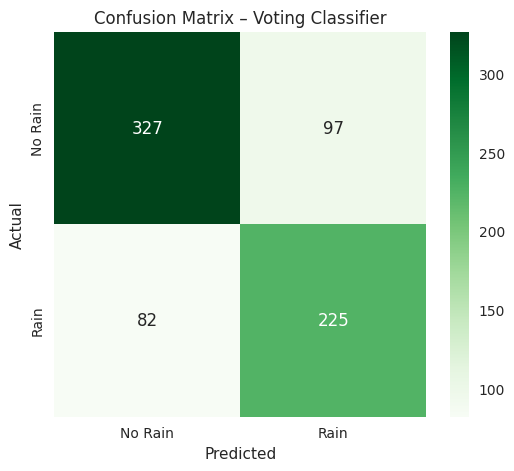

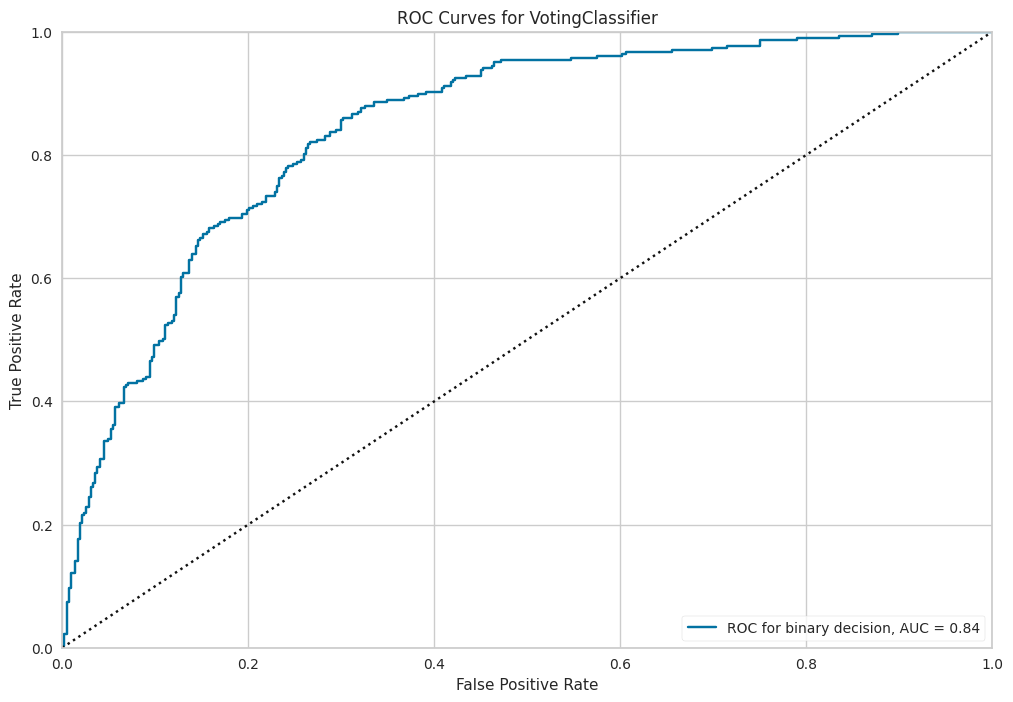

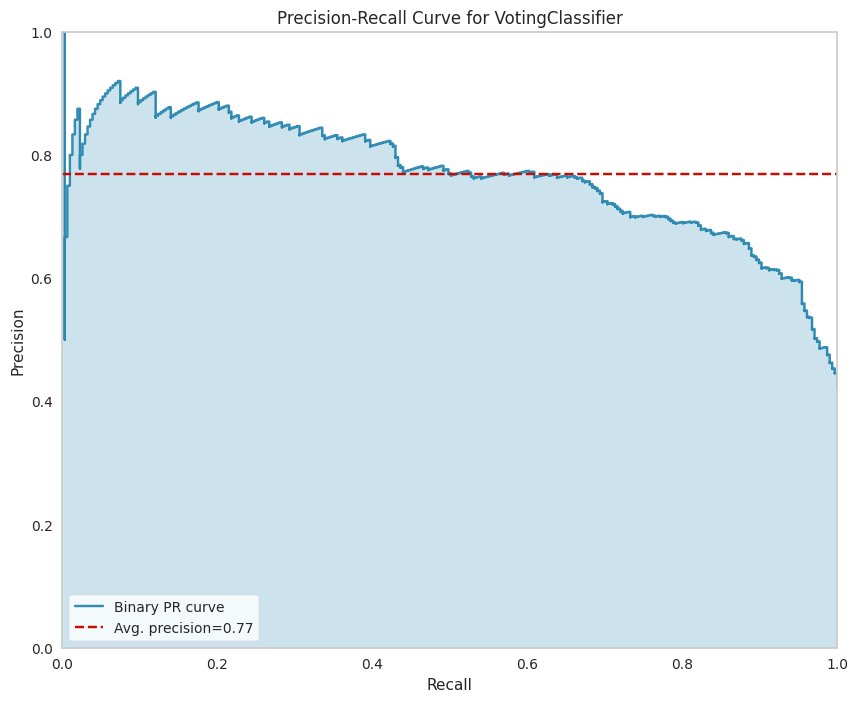

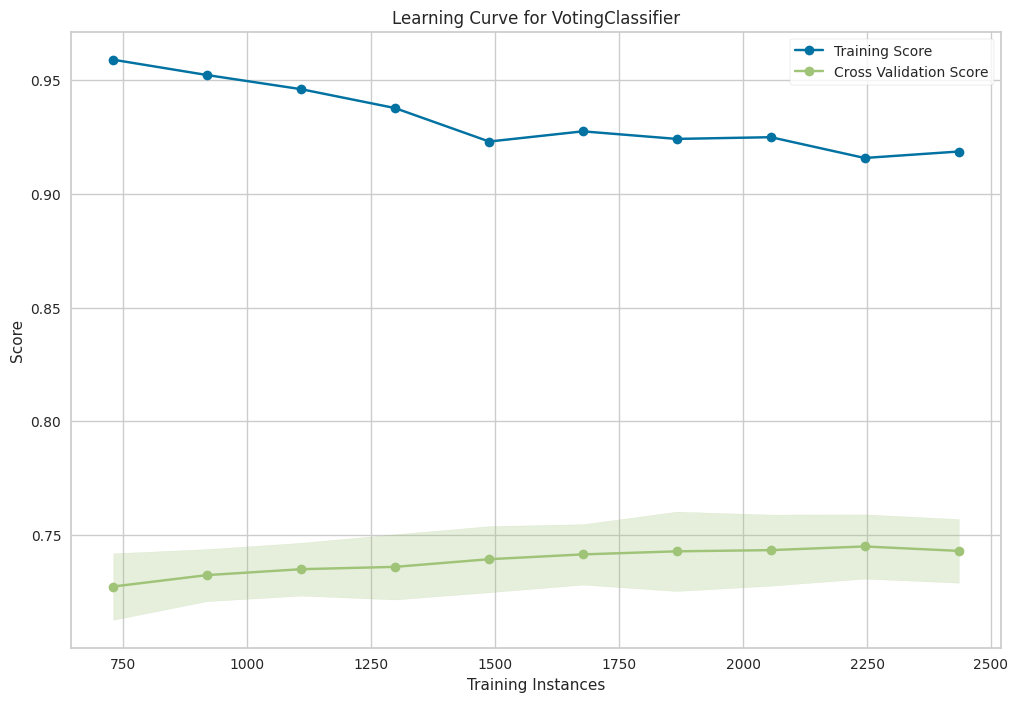

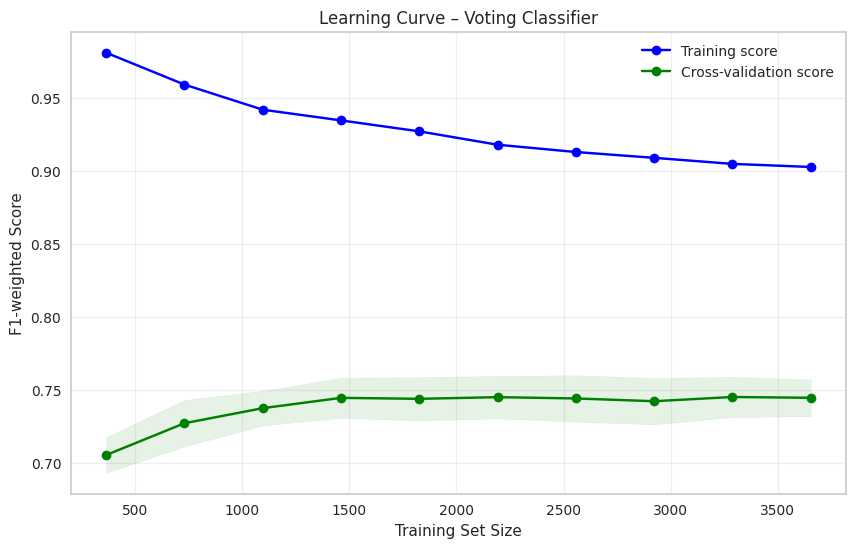

Soglia default (0.5): F1 = 0.7154
Soglia ottimale (0.377): F1 = 0.7556

=== Prestazioni con soglia ottimale ===
              precision    recall  f1-score   support

           0       0.88      0.68      0.77       424
           1       0.66      0.88      0.76       307

    accuracy                           0.76       731
   macro avg       0.77      0.78      0.76       731
weighted avg       0.79      0.76      0.76       731



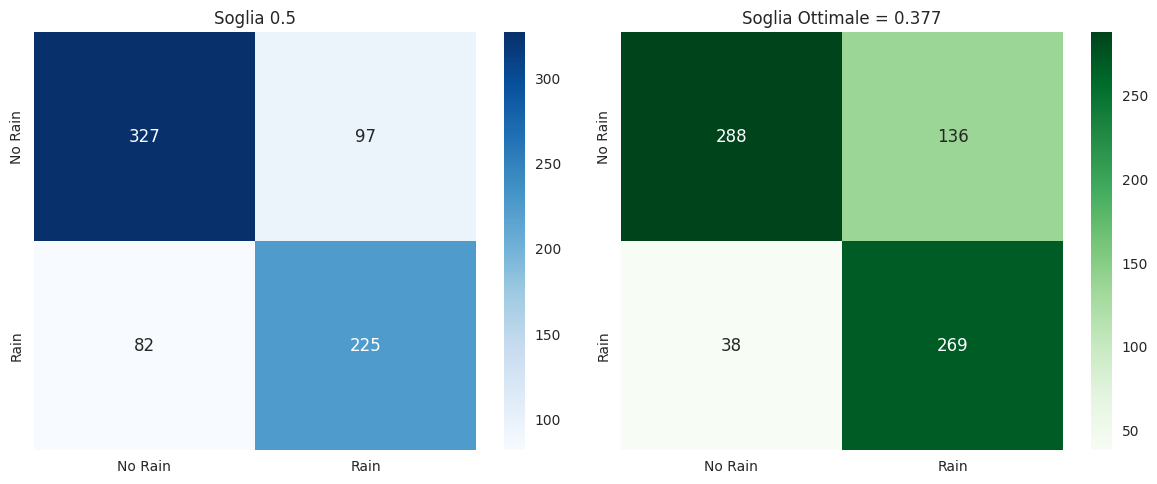

Distribuzione predizioni sull'intero dataset:
predicted_rain
0    0.574669
1    0.425331
Name: proportion, dtype: float64

✓ Risultati salvati in 'predictions.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# ============================================================================
# Installazione delle librerie necessarie
# ============================================================================
!pip install xgboost yellowbrick -q

# ============================================================================
# Import delle librerie
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (
    cross_val_score, GridSearchCV, TimeSeriesSplit, learning_curve
)
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, f1_score, precision_recall_curve
)

from xgboost import XGBClassifier
from yellowbrick.classifier import ROCAUC, PrecisionRecallCurve
from yellowbrick.model_selection import LearningCurve

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

# ============================================================================
# Caricamento del dataset (Google Colab)
# ============================================================================
from google.colab import files
print("📁 Caricare il file 'london_weather.csv'")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
data = pd.read_csv(filename, delimiter=';', encoding='ISO-8859-1')
print("✅ Dataset caricato")
print("Colonne:", data.columns.tolist())

# ============================================================================
# 1. Pulizia dei dati
# ============================================================================
# Sostituiamo i valori mancanti con la media della rispettiva colonna
columns_to_fill = [
    "cloud_cover", "sunshine", "global_radiation",
    "max_temp", "mean_temp", "min_temp",
    "precipitation", "pressure", "snow_depth"
]
for col in columns_to_fill:
    data[col] = data[col].fillna(data[col].mean())

data['date'] = pd.to_datetime(data['date'], format="%Y%m%d")
print(f"Duplicati: {data.duplicated().sum()}")

# ============================================================================
# 2. Feature Engineering
# ============================================================================
# Estraiamo informazioni temporali dalla data
data['day']   = data['date'].dt.day
data['month'] = data['date'].dt.month
data['year']  = data['date'].dt.year

# Precipitazione del giorno precedente (shift=1: nessun leakage sul target)
data['precip_lag1'] = data['precipitation'].shift(1).fillna(0)

# Media mobile delle precipitazioni sui 3 giorni PRECEDENTI.
# shift(1) esclude il giorno corrente dalla finestra: nessun leakage.
data['precip_ma3'] = (
    data['precipitation']
    .shift(1)
    .rolling(window=3, min_periods=1)
    .mean()
    .fillna(0)
)

# Ore di sole e copertura nuvolosa del giorno precedente:
# ottimi predittori naturali della pioggia, senza leakage.
data['sunshine_lag1'] = data['sunshine'].shift(1).fillna(0)
data['cloud_lag1']    = data['cloud_cover'].shift(1).fillna(0)

# Variabili dummy per il mese: catturano la stagionalità
data = pd.get_dummies(data, columns=['month'], prefix='month')

# ============================================================================
# 3. Creazione del target binario
# ============================================================================
# Definiamo "pioggia" come i giorni sopra il 60° percentile di precipitazione,
# ottenendo una distribuzione ~60% no pioggia / ~40% pioggia.
threshold = data['precipitation'].quantile(0.60)
print(f"Soglia pioggia: {threshold:.4f} mm")

data['y'] = (data['precipitation'] > threshold).astype(int)
print("Distribuzione target:")
print(data['y'].value_counts(normalize=True))

data = data.sort_values('date').reset_index(drop=True)

# ============================================================================
# 4. Matrice di correlazione – variabili originali + target
# ============================================================================
cols_corr = [
    "cloud_cover", "sunshine", "global_radiation",
    "max_temp", "mean_temp", "min_temp",
    "precipitation", "pressure", "snow_depth", "y"
]
plt.figure(figsize=(14, 10))
sns.heatmap(data[cols_corr].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)
plt.title("Matrice di Correlazione – Variabili originali + target")
plt.show()

# ============================================================================
# 5. Selezione delle feature
# ============================================================================
# Escludiamo global_radiation, max_temp, mean_temp, min_temp
# perché fortemente correlate tra loro (multicollinearità).
# Usiamo invece le lag features costruite in precedenza.
feature_columns = (
    ['cloud_cover', 'sunshine', 'pressure', 'snow_depth',
     'precip_lag1', 'precip_ma3', 'sunshine_lag1', 'cloud_lag1', 'day']
    + [col for col in data.columns if col.startswith('month_')]
)

X = data[feature_columns]
y = data['y']

print(f"Feature selezionate: {len(feature_columns)}")

# Heatmap dopo rimozione feature correlate
features_check = [
    'cloud_cover', 'sunshine', 'pressure', 'snow_depth',
    'precip_lag1', 'precip_ma3', 'sunshine_lag1', 'cloud_lag1', 'day', 'y'
]
plt.figure(figsize=(14, 10))
sns.heatmap(data[features_check].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)
plt.title("Matrice di Correlazione – Dopo rimozione feature correlate")
plt.show()

# ============================================================================
# 6. Split temporale train / test
# ============================================================================
# Usiamo uno split temporale (NON casuale) per rispettare la sequenzialità
# dei dati meteorologici ed evitare che il modello "veda il futuro".
# Training: fino al 2018 | Test: 2019-2020
train_mask = data['year'] < 2019
test_mask  = data['year'] >= 2019

X_train = X[train_mask].reset_index(drop=True)
y_train = y[train_mask].reset_index(drop=True)
X_test  = X[test_mask].reset_index(drop=True)
y_test  = y[test_mask].reset_index(drop=True)

print(f"Training set: {X_train.shape[0]} campioni")
print(f"Test set:     {X_test.shape[0]} campioni")
print(f"Distribuzione target training:\n{y_train.value_counts(normalize=True)}")

# ============================================================================
# 7. Definizione dei classificatori
# ============================================================================
rs = 42

# class_weight='balanced' penalizza gli errori sulla classe minoritaria,
# compensando lo sbilanciamento 60/40 senza generare dati sintetici.
# scale_pos_weight svolge la stessa funzione per XGBoost.
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

classifiers = {
    'LogisticRegression': LogisticRegression(
        random_state=rs, solver='liblinear', class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(
        random_state=rs, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(
        n_estimators=100, random_state=rs, class_weight='balanced'),
    'XGBoost': XGBClassifier(
        random_state=rs, scale_pos_weight=neg/pos),
    'SVC': SVC(
        probability=True, random_state=rs, class_weight='balanced'),
}

# ============================================================================
# 8. Cross-Validation e addestramento
# ============================================================================
# Pipeline: MinMaxScaler + classificatore.
# Lo scaler è DENTRO la pipeline: in ogni fold di CV viene adattato
# solo sul sotto-insieme di training, evitando leakage sui dati di validazione.
# TimeSeriesSplit rispetta l'ordine temporale dei dati.

tscv = TimeSeriesSplit(n_splits=5)

clf_names              = []
cv_means               = []
cv_stds                = []
test_accuracies        = []
confusion_matrices     = []
classification_reports = []
roc_aucs               = []
roc_fprs               = []
roc_tprs               = []
fitted_pipes           = {}

model_results = pd.DataFrame({'y_true': y_test.values})

def make_pipe(clf_instance):
    return Pipeline([
        ('scaler',     MinMaxScaler()),
        ('classifier', clf_instance)
    ])

for name, clf in classifiers.items():
    print(f"\n--- {name} ---")
    clf_names.append(name)

    # Cross-validation su X_train grezzo (scaler adattato dentro ogni fold)
    pipe_cv = make_pipe(clf)
    scores  = cross_val_score(
        pipe_cv, X_train, y_train,
        cv=tscv, scoring='f1_weighted', n_jobs=-1
    )
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f"F1-weighted CV: {scores.mean():.4f} (+/- {scores.std():.4f})")

    # Training finale su tutto X_train
    pipe_final = make_pipe(clf)
    pipe_final.fit(X_train, y_train)
    fitted_pipes[name] = pipe_final

    # Predizioni su X_test
    y_pred = pipe_final.predict(X_test)
    model_results[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    test_accuracies.append(acc)
    print(f"Test Accuracy: {acc:.4f}")

    confusion_matrices.append(confusion_matrix(y_test, y_pred))
    classification_reports.append(classification_report(y_test, y_pred))

    # Curva ROC
    y_proba = pipe_final.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_aucs.append(auc(fpr, tpr))
    roc_fprs.append(fpr)
    roc_tprs.append(tpr)

print("\n✓ Completato.")

# ============================================================================
# 9. Barplot punteggi Cross-Validation
# ============================================================================
cv_df = pd.DataFrame({
    'Algorithm':     clf_names,
    'CV Mean':       cv_means,
    'CV Std':        cv_stds,
    'Test Accuracy': test_accuracies
}).sort_values('CV Mean', ascending=False)

print(cv_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='CV Mean', y='Algorithm', data=cv_df, palette='viridis')
plt.errorbar(x=cv_df['CV Mean'], y=range(len(cv_df)),
             xerr=cv_df['CV Std'], fmt='none', ecolor='black', capsize=5)
plt.xlabel('F1-weighted (Cross-Validation)')
plt.title('Confronto Modelli – TimeSeriesSplit')
plt.xlim(0.6, 0.85)
plt.show()

# ============================================================================
# 10. Matrici di confusione
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, cm) in enumerate(zip(clf_names, confusion_matrices)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Rain', 'Rain'],
                yticklabels=['No Rain', 'Rain'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(len(clf_names), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

# ============================================================================
# 11. Classification report
# ============================================================================
for i, name in enumerate(clf_names):
    print(f"\n=== {name} ===")
    print(classification_reports[i])

# ============================================================================
# 12. Curve ROC
# ============================================================================
plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(clf_names)))

for i, name in enumerate(clf_names):
    plt.plot(roc_fprs[i], roc_tprs[i], color=colors[i], lw=2,
             label=f'{name} (AUC = {roc_aucs[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curve ROC – Confronto Modelli')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# ============================================================================
# 13. Correlazione tra le predizioni
# ============================================================================
plt.figure(figsize=(10, 8))
sns.heatmap(model_results.drop(columns=['y_true']).corr(),
            annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlazione tra le predizioni dei classificatori")
plt.show()

# ============================================================================
# 14. GridSearchCV (RandomForest e XGBoost)
# ============================================================================
# Ottimizziamo gli iperparametri dei due modelli migliori.
# La pipeline è la stessa (scaler + classificatore) e riceve X_train grezzo.

param_grids = {
    'RandomForest': {
        'classifier__n_estimators':      [50, 100],
        'classifier__max_depth':         [5, 8, None],
        'classifier__min_samples_split': [2, 5]
    },
    'XGBoost': {
        'classifier__n_estimators':  [100, 200],
        'classifier__max_depth':     [3, 6],
        'classifier__learning_rate': [0.01, 0.1]
    }
}

tscv_grid   = TimeSeriesSplit(n_splits=3)
best_models = {}

for name in ['RandomForest', 'XGBoost']:
    print(f"\n=== GridSearch per {name} ===")
    pipe = make_pipe(classifiers[name])
    gs   = GridSearchCV(pipe, param_grids[name], cv=tscv_grid,
                        scoring='f1_weighted', n_jobs=-1, verbose=1)
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    print(f"Migliori parametri: {gs.best_params_}")
    print(f"F1-weighted CV:     {gs.best_score_:.4f}")

# ============================================================================
# 15. Voting Classifier (ensemble)
# ============================================================================
# Combiniamo i due modelli ottimizzati in un ensemble soft voting.
# Ogni sub-estimatore è una pipeline con scaler interno:
# X_train grezzo viene scalato separatamente dentro ciascuno.

estimators  = [(name, best_models[name]) for name in best_models.keys()]
voting_clf  = VotingClassifier(estimators=estimators, voting='soft')
voting_clf.fit(X_train, y_train)

y_pred_voting  = voting_clf.predict(X_test)
y_proba_voting = voting_clf.predict_proba(X_test)[:, 1]

print("\n=== VOTING CLASSIFIER ===")
print(f"Accuracy:            {accuracy_score(y_test, y_pred_voting):.4f}")
print(f"F1-score (macro):    {f1_score(y_test, y_pred_voting, average='macro'):.4f}")
print(f"F1-score (weighted): {f1_score(y_test, y_pred_voting, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_voting))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_voting),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Rain', 'Rain'],
            yticklabels=['No Rain', 'Rain'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Voting Classifier')
plt.show()

# ============================================================================
# 16. Yellowbrick: ROC e Precision-Recall
# ============================================================================
plt.figure(figsize=(12, 8))
visualizer = ROCAUC(voting_clf,
                    classes=["no_precipitation", "precipitation"],
                    micro=False, macro=False, binary=True)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

plt.figure(figsize=(10, 8))
viz = PrecisionRecallCurve(voting_clf)
viz.fit(X_train, y_train)
viz.score(X_test, y_test)
viz.show()

# ============================================================================
# 17. Learning Curve
# ============================================================================
plt.figure(figsize=(12, 8))
visualizer = LearningCurve(
    voting_clf,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='f1_weighted',
    train_sizes=np.linspace(0.3, 1.0, 10),
    n_jobs=-1
)
visualizer.fit(X_train, y_train)
visualizer.show()

train_sizes, train_scores, test_scores = learning_curve(
    voting_clf, X_train, y_train,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-',
         color='blue', label='Training score')
plt.fill_between(train_sizes,
                 np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                 np.mean(train_scores, axis=1) + np.std(train_scores, axis=1),
                 alpha=0.1, color='blue')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-',
         color='green', label='Cross-validation score')
plt.fill_between(train_sizes,
                 np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
                 np.mean(test_scores, axis=1) + np.std(test_scores, axis=1),
                 alpha=0.1, color='green')
plt.xlabel('Training Set Size')
plt.ylabel('F1-weighted Score')
plt.title('Learning Curve – Voting Classifier')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

# ============================================================================
# 18. Ottimizzazione della soglia di decisione
# ============================================================================
# La soglia di default 0.5 non è sempre ottimale.
# Cerchiamo la soglia che massimizza l'F1-score sul test set.
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_voting)
f1_scores_thr  = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx       = np.argmax(f1_scores_thr[:-1])
best_threshold = thresholds[best_idx]

print(f"Soglia default (0.5): F1 = {f1_score(y_test, y_proba_voting >= 0.5):.4f}")
print(f"Soglia ottimale ({best_threshold:.3f}): F1 = {f1_scores_thr[best_idx]:.4f}")

y_pred_adj = (y_proba_voting >= best_threshold).astype(int)
print("\n=== Prestazioni con soglia ottimale ===")
print(classification_report(y_test, y_pred_adj))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_proba_voting >= 0.5),
            annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
ax1.set_title('Soglia 0.5')
sns.heatmap(confusion_matrix(y_test, y_pred_adj),
            annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
ax2.set_title(f'Soglia Ottimale = {best_threshold:.3f}')
plt.tight_layout()
plt.show()

# ============================================================================
# 19. Predizioni sul dataset completo e salvataggio
# ============================================================================
X_all = data[feature_columns]

data['predicted_rain'] = voting_clf.predict(X_all)
data['prob_rain']      = voting_clf.predict_proba(X_all)[:, 1]

print("Distribuzione predizioni sull'intero dataset:")
print(data['predicted_rain'].value_counts(normalize=True))

data[['date', 'precipitation', 'y', 'predicted_rain', 'prob_rain']].to_csv(
    'predictions.csv', index=False
)
print("\n✓ Risultati salvati in 'predictions.csv'")
files.download('predictions.csv')